# Zika - Baseline Model

In [3]:
%reload_ext autoreload
%autoreload 2
from my_lib import *

## Imports

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
location = "D"
df_z = pd.read_feather(f"data/zika_{location}.feather")
df_d = pd.read_feather(f"data/dengue_{location}.feather")
df_score = pd.read_feather(f"data/score_{location}.feather")
df_w = pd.read_feather(f"data/weather_{location}.feather")

In [6]:
target = "cases"

df_z['Month'] = df_z['EW_start_date'].dt.month
z_features = ['EW', 'EW_start_date', 'pop', 'Month']
df_z[z_features].head(1)

,EW,EW_start_date,pop,Month
1043,201501,2015-01-04,890480,1


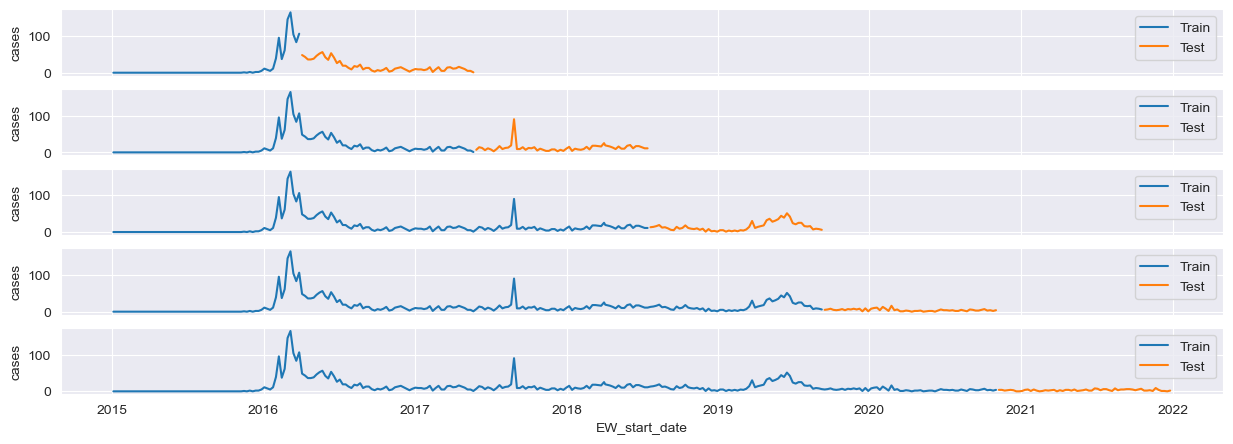

In [7]:
cv = TimeSeriesSplit(gap=0, n_splits=5, test_size=None)

fig, axs = plt.subplots(cv.n_splits, 1, figsize=(15, 5), sharex=True)

for (train_idx, test_idx), ax in zip(cv.split(df_z), axs):
    df_train = df_z.iloc[train_idx]
    df_test = df_z.iloc[test_idx]

    sns.lineplot(data=df_train, x="EW_start_date", y=target, ax=ax, label='Train')
    sns.lineplot(data=df_test, x="EW_start_date", y=target, ax=ax, label='Test')
    ax.legend()